In [23]:
#a.
import pandas as pd
import numpy as np
#creating the matrix
data = {
    'Col0': [1, 3, 5, 7, 9, 11],
    'Col1': [2, 4, 6, 8, 10, 12]
}
idx = ['Idx0', 'Idx1', 'Idx2', 'Idx3', 'Idx4', 'Idx5']

df = pd.DataFrame(data, index=idx)

print("Initial matrix:")
print(df)

Initial matrix:
      Col0  Col1
Idx0     1     2
Idx1     3     4
Idx2     5     6
Idx3     7     8
Idx4     9    10
Idx5    11    12


In [24]:
#modify element row 3, column 1 zero-based (column 2 doesn't exist)
df.iloc[3, 1] += 1
#modify the element with index 0, column 1
df.at['Idx0', 'Col1'] += 2
print("Modified Matrix:")
print(df)

Modified Matrix:
      Col0  Col1
Idx0     1     4
Idx1     3     4
Idx2     5     6
Idx3     7     9
Idx4     9    10
Idx5    11    12


In [25]:
# b.
x = 0.4
result_b = np.log((x * np.sinh(x)) / (1 + np.exp(x**2 / 2)))

print(f"The result is: {result_b}")

The result is: -2.5400025589406656


In [27]:
# c.
from scipy.optimize import minimize_scalar

# Define the function (we use a minus sign to find the maximum)
def function_to_maximize(x, mu=1):
    return -(x * np.exp(-(x - mu)**2 / 2))

# Find the maximum using minimize_scalar
res = minimize_scalar(function_to_maximize)

print(f"The function reaches its maximum at x = {res.x}")
print(f"The maximum value is = {-res.fun}")

The function reaches its maximum at x = 1.6180339988009027
The maximum value is = 1.336733323596827


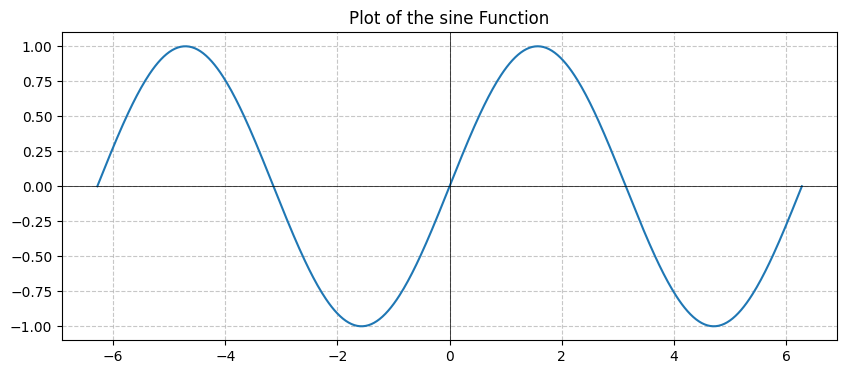

In [36]:
# d.
import matplotlib.pyplot as plt

# 1. Plot y = sin(x) for x in [-2pi, 2pi]
x_sin = np.linspace(-2 * np.pi, 2 * np.pi, 500)
y_sin = np.sin(x_sin)

plt.figure(figsize=(10, 4))
plt.plot(x_sin, y_sin, label='y = sin(x)')
plt.title('Plot of the Sine Function')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

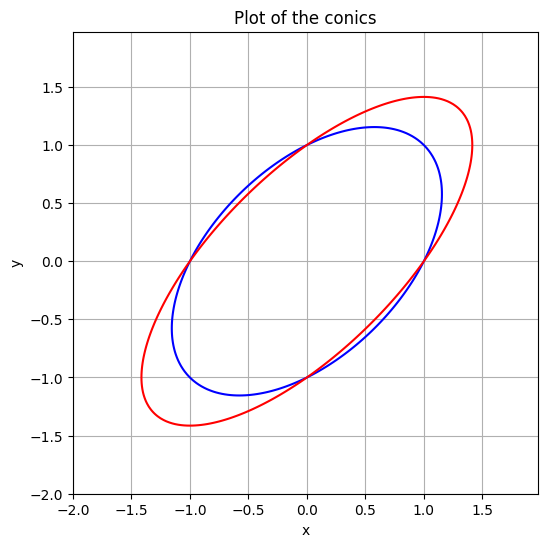

In [39]:
d = 0.025
x_range = np.arange(-2.0, 2.0, d)
y_range = np.arange(-2.0, 2.0, d)
X, Y = np.meshgrid(x_range, y_range)

rho_1 = 1 / 2
rho_2 = 1 / np.sqrt(2)
plt.figure(figsize=(6, 6))
# Let's write the equations
Z_1 = (X **2) - (2 * rho_1 * X * Y) + (Y **2)
Z_2 = (X **2) - (2 * rho_2 * X * Y) + (Y **2)

#Since the equations are implicit, we use contour, which only draws lines where the formula is equal to 1
plt.contour(X, Y, Z_1, levels=[1], colors='blue')
plt.contour(X, Y, Z_2, levels=[1], colors='red')
plt.title('Plot of the conics')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [42]:
# e.
import statsmodels.api as sm

# X is the independent variable (predictor)
# y is the dependent variable (what we want to predict)
X = df['Col0']
y = df['Col1']
# We must add the constant manually since it's not included by default.
X_with_intercept = sm.add_constant(X)
# Create the linear model
model = sm.OLS(y, X_with_intercept).fit()

print("Regression Results with 6 observations:")
params = model.params
intercept = params.iloc[0]
slope = params.iloc[1]
print("Parameters:")
print(f"Intercept: {intercept:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Equation: y = {slope:.4f}x + {intercept:.4f}")

Regression Results with 6 observations:
Parameters:
Intercept: 2.2714
Slope: 0.8714
Equation: y = 0.8714x + 2.2714


In [45]:
#!pip install QuantLib

In [46]:
#f
import QuantLib as ql
#Year Fraction 30/360 European
start_date = ql.Date(19, 2, 2008)
end_date = ql.Date(19, 5, 2008)
day_count = ql.Thirty360(ql.Thirty360.European)

year_frac = day_count.yearFraction(start_date, end_date)

print(f"Year Fraction (30/360 European): {year_frac}")


Year Fraction (30/360 European): 0.25


In [50]:
#Monthly modified adjusted calendar
effective_date = ql.Date(31, 10, 2025)
termination_date = effective_date + ql.Period(6, ql.Months)
calendar = ql.TARGET()

print("\nMonthly Adjusted Schedule:")
#We use a for cycle to compute the next 6 months
for month in range(7):
  new_date = calendar.advance(effective_date, month, ql.Months, ql.ModifiedFollowing)
  print(f"Month {month},: {new_date} ")



Monthly Adjusted Schedule:
Month 0,: October 31st, 2025 
Month 1,: November 28th, 2025 
Month 2,: December 31st, 2025 
Month 3,: January 30th, 2026 
Month 4,: February 27th, 2026 
Month 5,: March 31st, 2026 
Month 6,: April 30th, 2026 
